# Python for Health, Economic, and Social Science
## Lab 5 — Instructor Solution & Expansion Notes

**Course:** LCDS, Nuffield College Oxford  
**Day 5 theme:** Modelling, ML, NLP — applied to health, social, and economic outcomes

---

### Instructor framing for Day 5

Day 5 is deliberately ambitious. Students with no prior coding background have now built up five days of vocabulary, and this session shows what that vocabulary can *do*. The three parts cover:

1. **statsmodels OLS** — inference-first modelling (p-values, R², residuals): the economist/epidemiologist's primary tool
2. **scikit-learn** — predictive modelling pipeline: classification, evaluation, unsupervised segmentation
3. **NLTK** — rule-based NLP: tokenisation, frequency analysis, triage scoring

Emphasise: these are the same foundations used in NHS Digital dashboards, ONS analyses, and WHO surveillance reports.

---
## Part A: StatsModels for Health and Social Outcome Modelling

### Q1: Imports and setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.cluster         import KMeans
from sklearn.metrics         import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, precision_recall_fscore_support
)

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize      import wordpunct_tokenize
from nltk.probability   import FreqDist
from nltk.collocations  import BigramCollocationFinder
from nltk.metrics       import BigramAssocMeasures

rng = np.random.default_rng(42)
print("Libraries loaded, RNG seeded.")

Libraries loaded, RNG seeded.


>  `np.random.default_rng(42)` is the **modern** NumPy random interface (Generator API, available since NumPy 1.17). Prefer it over the legacy `np.random.seed(42)` / `np.random.normal()` pattern. It is thread-safe, composable, and produces better statistical properties.
>
> For scikit-learn functions that take `random_state=`, pass integer 42 directly — they maintain their own RNG internally.
>
> **Expansion — checking library versions:**
```python
import sklearn, statsmodels
print(f"sklearn  {sklearn.__version__}")
print(f"statsmodels {statsmodels.__version__}")
```

### Q2: Build a synthetic policy dataset

In [2]:
areas = [
    "Northside", "Central", "Riverside", "Eastbrook", "Hilltown",
    "Westgate", "Southdowns", "Moorfield", "Porthill", "Lakeside",
    "Greenlea", "Blakewell", "Ironbridge", "Briarwood", "Coldmoor",
    "Dunhollow", "Elmhaven", "Fernshaw", "Graymere", "Hartsend"
]
months = list(range(1, 13))
n_areas = len(areas)
n_months = len(months)
N = n_areas * n_months   # 240 rows

# Per-area fixed effects (simulate structural deprivation)
area_deprivation = {a: rng.uniform(10, 80) for a in areas}
area_income      = {a: rng.uniform(20_000, 45_000) for a in areas}

rows = []
for area in areas:
    dep   = area_deprivation[area]
    inc   = area_income[area]
    for month in months:
        unemp  = np.clip(dep / 500 + rng.normal(0.08, 0.025), 0.02, 0.30)
        chronic = np.clip(dep / 400 + rng.normal(0.18, 0.04), 0.05, 0.45)
        absence = np.clip(dep / 700 + unemp * 0.4 + rng.normal(0.07, 0.02), 0.01, 0.25)
        prev_v  = np.clip(inc / 1000 - dep / 20 + rng.normal(20, 5), 2, 60)
        soc_sp  = np.clip(dep * 8 + rng.normal(500, 100), 100, 2000)
        winter  = 1 if month in (12, 1, 2, 3) else 0
        admissions = (
            0.8 * unemp * 100
            + 1.2 * chronic * 100
            + 0.5 * absence * 100
            - 0.3 * prev_v
            - 0.002 * soc_sp
            + 3.0 * winter
            - 0.0002 * inc
            + 0.05 * dep
            + rng.normal(0, 2)
            + 10
        )
        rows.append({
            "area":                        area,
            "month":                       month,
            "median_income":               round(inc, 0),
            "deprivation_index":           round(dep, 1),
            "unemployment_rate":           round(unemp, 4),
            "school_absence_rate":         round(absence, 4),
            "chronic_rate":                round(chronic, 4),
            "preventive_visits":           round(prev_v, 1),
            "social_support_spend":        round(soc_sp, 0),
            "winter":                      winter,
            "emergency_admissions_per_1k": round(admissions, 2)
        })

health_df = pd.DataFrame(rows)
print(f"{health_df.shape} — {health_df.dtypes.value_counts().to_dict()}")
print(health_df.head())

(240, 11) — {dtype('float64'): 8, dtype('int64'): 2, dtype('O'): 1}
        area  month  median_income  deprivation_index  unemployment_rate  \
0  Northside      1        38952.0               64.2             0.2269   
1  Northside      2        38952.0               64.2             0.2301   
2  Northside      3        38952.0               64.2             0.1719   
3  Northside      4        38952.0               64.2             0.1867   
4  Northside      5        38952.0               64.2             0.2261   

   school_absence_rate  chronic_rate  preventive_visits  social_support_spend  \
0               0.2391        0.3622               56.9                1025.0   
1               0.2500        0.3494               56.1                1042.0   
2               0.2210        0.3277               52.5                 986.0   
3               0.2027        0.3792               54.1                1030.0   
4               0.2452        0.3722               53.4               

>  The data-generating process (DGP) here is intentionally *structural* — deprivation drives unemployment, which drives admissions. This makes coefficients interpretable and recoverable by OLS, which is the pedagogical point.
>
> In real research, the DGP is unknown — the model is always an approximation. Discussing the assumptions embedded in simulation is a good bridge to discussing model assumptions (linearity, homoscedasticity, no omitted variable bias).

### Q3: Diagnostics and risk label

In [3]:
# Q3
print("Shape:", health_df.shape)
print(health_df.head())

cols = ["emergency_admissions_per_1k", "unemployment_rate", "school_absence_rate", "median_income"]
print(health_df[cols].describe().round(3))

threshold_70 = health_df["emergency_admissions_per_1k"].quantile(0.70)
health_df["high_risk"] = (health_df["emergency_admissions_per_1k"] >= threshold_70).astype(int)

print(f"\n70th percentile threshold: {threshold_70:.2f}")
print(health_df["high_risk"].value_counts())

Shape: (240, 11)
        area  month  median_income  deprivation_index  unemployment_rate  \
0  Northside      1        38952.0               64.2             0.2269   
1  Northside      2        38952.0               64.2             0.2301   
2  Northside      3        38952.0               64.2             0.1719   
3  Northside      4        38952.0               64.2             0.1867   
4  Northside      5        38952.0               64.2             0.2261   

   school_absence_rate  chronic_rate  preventive_visits  social_support_spend  \
0               0.2391        0.3622               56.9                1025.0   
1               0.2500        0.3494               56.1                1042.0   
2               0.2210        0.3277               52.5                 986.0   
3               0.2027        0.3792               54.1                1030.0   
4               0.2452        0.3722               53.4                1099.0   

   winter  emergency_admissions_per_1k 

>  The 70th percentile threshold is a **policy decision**, not a statistical one. Different contexts justify different thresholds — in NHS triage, the cost of a false negative (missing high-risk patient) typically exceeds the cost of a false positive. This directly motivates Q11 (threshold sensitivity analysis).
>
> **Expansion — class imbalance considerations:**
```python
# Class imbalance ratio:
ratio = health_df['high_risk'].value_counts(normalize=True).round(2)
print(ratio)
# If the minority class is < 10%, consider: SMOTE oversampling,
# class_weight='balanced' in sklearn, or precision-recall AUC instead of ROC AUC.
```

### Q4: OLS model for emergency admissions

In [4]:
# Q4
formula = (
    "emergency_admissions_per_1k ~ "
    "unemployment_rate + chronic_rate + school_absence_rate + "
    "preventive_visits + social_support_spend + winter + "
    "median_income + deprivation_index"
)

ols_model = smf.ols(formula, data=health_df).fit()
print(ols_model.summary())

                                 OLS Regression Results                                
Dep. Variable:     emergency_admissions_per_1k   R-squared:                       0.978
Model:                                     OLS   Adj. R-squared:                  0.978
Method:                          Least Squares   F-statistic:                     1301.
Date:                         Fri, 20 Mar 2026   Prob (F-statistic):          1.89e-187
Time:                                 09:17:12   Log-Likelihood:                -507.83
No. Observations:                          240   AIC:                             1034.
Df Residuals:                              231   BIC:                             1065.
Df Model:                                    8                                         
Covariance Type:                     nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

In [1]:
# print the summary in latex from ols_model.summary()
print(ols_model.summary().as_latex())

NameError: name 'ols_model' is not defined

In [5]:
# print the result in a more readable format with the ols_model
coef_df = pd.DataFrame({
    "Variable": ols_model.params.index,
    "Coefficient": ols_model.params.values,
    "Std. Error": ols_model.bse.values,
    "t-value": ols_model.tvalues.values,
    "p-value": ols_model.pvalues.values
})
print(coef_df.round(4))

               Variable  Coefficient  Std. Error  t-value  p-value
0             Intercept       9.9166      1.5221   6.5153   0.0000
1     unemployment_rate      79.9977      6.2037  12.8952   0.0000
2          chronic_rate     118.5658      3.4893  33.9797   0.0000
3   school_absence_rate      40.1758      7.1668   5.6058   0.0000
4     preventive_visits      -0.3103      0.0281 -11.0466   0.0000
5  social_support_spend       0.0011      0.0014   0.7474   0.4556
6                winter       3.2732      0.2843  11.5140   0.0000
7         median_income      -0.0002      0.0000  -6.0985   0.0000
8     deprivation_index       0.0554      0.0219   2.5332   0.0120


In [6]:
# print in latex format
latex_table = coef_df.round(4).to_latex(index=False)
print("\nLaTeX Table:\n")
print(latex_table)


LaTeX Table:

\begin{tabular}{lrrrr}
\toprule
Variable & Coefficient & Std. Error & t-value & p-value \\
\midrule
Intercept & 9.916600 & 1.522100 & 6.515300 & 0.000000 \\
unemployment_rate & 79.997700 & 6.203700 & 12.895200 & 0.000000 \\
chronic_rate & 118.565800 & 3.489300 & 33.979700 & 0.000000 \\
school_absence_rate & 40.175800 & 7.166800 & 5.605800 & 0.000000 \\
preventive_visits & -0.310300 & 0.028100 & -11.046600 & 0.000000 \\
social_support_spend & 0.001100 & 0.001400 & 0.747400 & 0.455600 \\
winter & 3.273200 & 0.284300 & 11.514000 & 0.000000 \\
median_income & -0.000200 & 0.000000 & -6.098500 & 0.000000 \\
deprivation_index & 0.055400 & 0.021900 & 2.533200 & 0.012000 \\
\bottomrule
\end{tabular}



>  The `statsmodels.formula.api` (R-style formula strings) is usually more readable than `statsmodels.api` with manual matrix construction. Both produce identical results.
>
> **Reading the summary:**
> - `R-squared`: proportion of variation explained (higher = better fit)
> - `Adj. R-squared`: penalises for extra predictors — use this for model comparison
> - `P>|t|`: p-value for the null hypothesis that the coefficient = 0
> - `coef`: the expected change in admissions per unit increase in that predictor, *holding all others constant*
> - `F-statistic` / `Prob (F-statistic)`: tests whether *any* predictor is useful (overall model significance)
>
> **Expansion — robust standard errors (common in economics and epidemiology):**
```python
# Heteroscedasticity-consistent (HC1) standard errors:
ols_robust = smf.ols(formula, data=health_df).fit(cov_type='HC1')
print(ols_robust.summary())
```
> When variance differs across areas (urban vs rural), OLS standard errors may be too small — robust SEs are conservative and safer.

### Q5: Coefficients and model quality

In [7]:
# Q5
coeff_table = pd.DataFrame({
    "coefficient": ols_model.params,
    "p_value":     ols_model.pvalues
}).drop("Intercept").sort_values("coefficient", key=abs, ascending=False).round(4)

coeff_table["significant"] = coeff_table["p_value"] < 0.05
print(coeff_table)

from sklearn.metrics import mean_squared_error, r2_score
y_true = health_df["emergency_admissions_per_1k"]
y_pred = ols_model.fittedvalues

print(f"\nMSE:  {mean_squared_error(y_true, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}")
print(f"R²:   {r2_score(y_true, y_pred):.4f}")

                      coefficient  p_value  significant
chronic_rate             118.5658   0.0000         True
unemployment_rate         79.9977   0.0000         True
school_absence_rate       40.1758   0.0000         True
winter                     3.2732   0.0000         True
preventive_visits         -0.3103   0.0000         True
deprivation_index          0.0554   0.0120         True
social_support_spend       0.0011   0.4556        False
median_income             -0.0002   0.0000         True

MSE:  4.031
RMSE: 2.008
R²:   0.9783


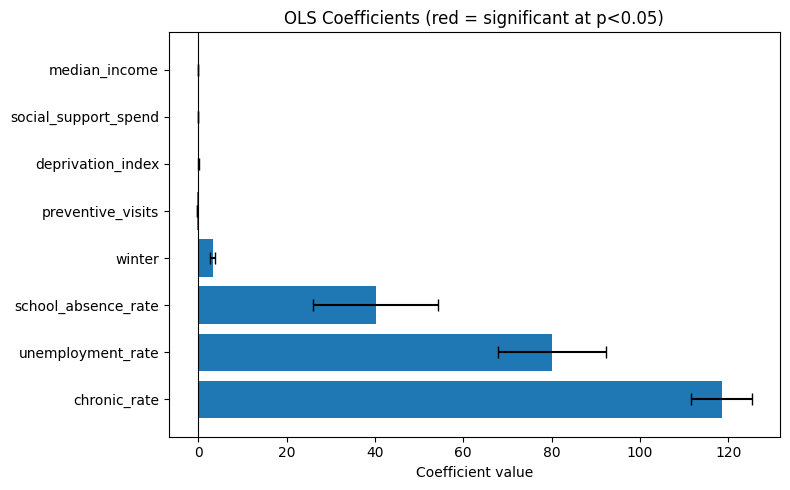

In [13]:
conf_int = ols_model.conf_int().drop('Intercept')
conf_int.columns = ['lower_95', 'upper_95']
coeff_plot = coeff_table.join(conf_int)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coeff_plot.index, coeff_plot['coefficient'],
        xerr=[
            coeff_plot['coefficient'] - coeff_plot['lower_95'],
            coeff_plot['upper_95'] - coeff_plot['coefficient']
        ], #color=['orange' if s else 'steelblue' for s in coeff_plot['significant']],
        capsize=4)
ax.axvline(0, color='k', linewidth=0.8)
ax.set(title='OLS Coefficients (red = significant at p<0.05)', xlabel='Coefficient value')
plt.tight_layout(); plt.show()

>  RMSE is in the same units as the outcome (admissions per 1,000), making it interpretable as an average prediction error. An RMSE of 2 means the model is off by ~2 admissions/1,000 on average.
>
> **Expansion — visualising coefficients with confidence intervals:**
```python
conf_int = ols_model.conf_int().drop('Intercept')
conf_int.columns = ['lower_95', 'upper_95']
coeff_plot = coeff_table.join(conf_int)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coeff_plot.index, coeff_plot['coefficient'],
        xerr=[
            coeff_plot['coefficient'] - coeff_plot['lower_95'],
            coeff_plot['upper_95'] - coeff_plot['coefficient']
        ], color=['tomato' if s else 'steelblue' for s in coeff_plot['significant']],
        capsize=4)
ax.axvline(0, color='k', linewidth=0.8)
ax.set(title='OLS Coefficients (red = significant at p<0.05)', xlabel='Coefficient value')
plt.tight_layout(); plt.show()
```

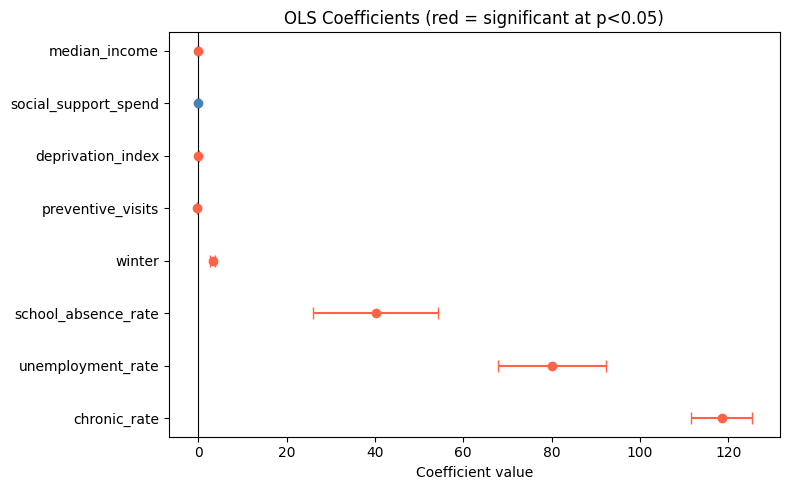

In [15]:
conf_int = ols_model.conf_int().drop('Intercept')
conf_int.columns = ['lower_95', 'upper_95']
coeff_plot = coeff_table.join(conf_int)

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(coeff_plot))
colors = ['tomato' if s else 'steelblue' for s in coeff_plot['significant']]

for i, (coef, low, up, c) in enumerate(zip(
    coeff_plot['coefficient'],
    coeff_plot['lower_95'],
    coeff_plot['upper_95'],
    colors
)):
    ax.errorbar(
        x=coef, y=i,
        xerr=np.array([[coef - low], [up - coef]]),
        fmt='o', color=c, ecolor=c,
        capsize=4, markersize=6
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(coeff_plot.index)
ax.axvline(0, color='k', linewidth=0.8)
ax.set(title='OLS Coefficients (red = significant at p<0.05)', xlabel='Coefficient value')
plt.tight_layout(); plt.show()

### Q6: Residual diagnostics + scenario prediction

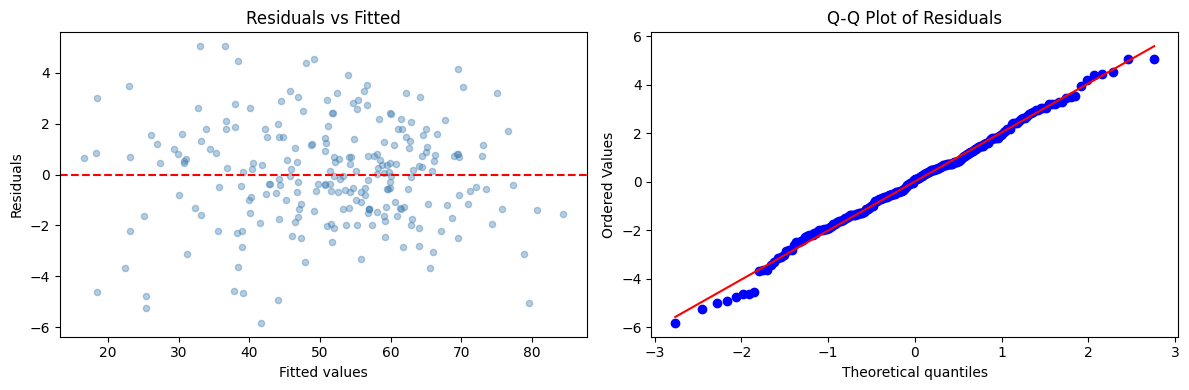

In [ ]:
# Q6: Diagnostic plots
residuals = ols_model.resid

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Fitted
ax1.scatter(ols_model.fittedvalues, residuals, alpha=0.4, s=20, color='steelblue')
ax1.axhline(0, color='red', linestyle='--')
ax1.set(xlabel="Fitted values", ylabel="Residuals",
        title="Residuals vs Fitted")

# Q-Q plot via scipy ()
# qqplot (full name: quantile-quantile plot) is a diagnostic tool to assess if the residuals are normally distributed, which is an assumption of OLS regression. 
# It plots the quantiles of the residuals against the quantiles of a normal distribution. 
# If the points approximately lie on a straight line, it suggests that the residuals are normally distributed.

import scipy.stats as stats
stats.probplot(residuals, dist='norm', plot=ax2)
ax2.set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [17]:
# Q6: Scenario prediction
scenarios = pd.DataFrame([
    {"scenario": "High stress area (baseline)",
     "unemployment_rate": 0.15, "chronic_rate": 0.28, "school_absence_rate": 0.11,
     "preventive_visits": 12, "social_support_spend": 600, "winter": 0,
     "median_income": 25000, "deprivation_index": 65},
    {"scenario": "Moderate intervention",
     "unemployment_rate": 0.12, "chronic_rate": 0.24, "school_absence_rate": 0.09,
     "preventive_visits": 22, "social_support_spend": 900, "winter": 0,
     "median_income": 28000, "deprivation_index": 52},
    {"scenario": "Stronger intervention",
     "unemployment_rate": 0.08, "chronic_rate": 0.20, "school_absence_rate": 0.06,
     "preventive_visits": 35, "social_support_spend": 1400, "winter": 0,
     "median_income": 32000, "deprivation_index": 38},
])

predictions = ols_model.predict(scenarios)
scenarios["predicted_admissions_per_1k"] = predictions.round(2)
print(scenarios[["scenario", "predicted_admissions_per_1k"]])

                      scenario  predicted_admissions_per_1k
0  High stress area (baseline)                        55.08
1        Moderate intervention                        43.03
2        Stronger intervention                        28.80


>  Scenario prediction turns a statistical model into a **policy tool**. The question "what would admissions look like if we raised preventive care by 20 visits per area?" is now answerable in one line. Connect this to health technology assessment (NICE) and cost-effectiveness frameworks.
>
> **Expansion — prediction intervals vs confidence intervals:**
```python
# get_prediction() returns both types of uncertainty:
pred_obj = ols_model.get_prediction(scenarios)
print(pred_obj.summary_frame()[['obs_ci_lower', 'mean', 'obs_ci_upper']])
# obs_ci = confidence around a single new observation (wide)
# mean_ci = confidence around the *expected* value (narrower)
```

---
## Part B: Scikit-learn for Risk Prediction and Segmentation

### Q7: Train/test split

In [18]:
feature_cols = [
    "unemployment_rate", "chronic_rate", "school_absence_rate",
    "preventive_visits", "social_support_spend", "winter",
    "median_income", "deprivation_index"
]

X = health_df[feature_cols]
y = health_df["high_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} {type(X_train)}, Test: {X_test.shape} {type(X_test)}")
print(f"Train class balance: {y_train.mean():.2%} high_risk")
print(f"Test  class balance: {y_test.mean():.2%} high_risk")

Train: (168, 8) <class 'pandas.core.frame.DataFrame'>, Test: (72, 8) <class 'pandas.core.frame.DataFrame'>
Train class balance: 29.76% high_risk
Test  class balance: 30.56% high_risk


In [19]:
X_train

,unemployment_rate,chronic_rate,school_absence_rate,preventive_visits,social_support_spend,winter,median_income,deprivation_index
178,0.1947,0.3162,0.2362,48.3,713.0,0,31739.0,41.0
87,0.2113,0.3119,0.2500,41.5,1004.0,0,21095.0,65.0
92,0.2556,0.2765,0.2395,35.7,968.0,0,21095.0,65.0
101,0.1333,0.1582,0.1537,41.0,837.0,0,23857.0,19.0
184,0.1322,0.2724,0.1693,41.5,809.0,0,24737.0,25.9
...,...,...,...,...,...,...,...,...
144,0.1746,0.4001,0.2140,39.0,948.0,1,28146.0,55.1
230,0.1830,0.3072,0.2285,60.0,952.0,1,36745.0,54.2
113,0.1543,0.2429,0.1891,60.0,604.0,0,37076.0,41.5
10,0.1989,0.3924,0.2341,59.4,920.0,0,38952.0,64.2


>  `stratify=y` ensures the class distribution is preserved in both splits. Without it, a small test set might by chance contain very few (or very many) positive cases, making evaluation metrics unreliable. Always stratify for binary classification unless you have a specific reason not to.
>
> **Expansion — cross-validation:**
```python
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores = cross_val_score(pipe, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"5-fold CV ROC AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
```
> Cross-validation gives a more honest estimate of performance than a single train/test split, especially for small datasets.

In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=42))
])

cv_scores = cross_val_score(pipe, X, y, cv=StratifiedKFold(5), scoring='roc_auc')
print(f"5-fold CV ROC AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

5-fold CV ROC AUC: 0.987 ± 0.012


### Q8: Logistic regression pipeline

In [22]:
# Q8
scaler   = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform on train
X_test_sc  = scaler.transform(X_test)        # transform only on test (crucial!)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr    = lr.predict(X_test_sc)
y_proba_lr   = lr.predict_proba(X_test_sc)[:, 1]

print("First 10 predictions:", y_pred_lr[:10], type(y_pred_lr))
print("First 10 probabilities:", y_proba_lr[:10].round(3), type(y_proba_lr))

First 10 predictions: [0 1 0 1 0 0 0 0 0 0] <class 'numpy.ndarray'>
First 10 probabilities: [0.    0.705 0.    0.793 0.394 0.031 0.039 0.054 0.028 0.023] <class 'numpy.ndarray'>


>  The critical mistake to flag: **never `fit_transform` the test set**. The scaler must compute mean/std from the training data only, then apply those same parameters to the test data. Fitting on the test set leaks information and inflates performance estimates.
>
> The sklearn `Pipeline` object automates this correctly:
```python
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=1000, random_state=42))
])
pipeline.fit(X_train, y_train)        # fit both steps on train
y_pred = pipeline.predict(X_test)     # transforms test with train params
```
> Using `Pipeline` is the professional standard and prevents data leakage by construction.

### Q9: Logistic regression evaluation

In [23]:
# Q9
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_proba_lr)

print(f"Logistic Regression — Accuracy: {lr_acc:.3f}, ROC AUC: {lr_auc:.3f}\n")

# Labeled confusion matrix:
cm = confusion_matrix(y_test, y_pred_lr)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Predicted 0", "Predicted 1"])
print("Confusion matrix:\n", cm_df)

print("\nClassification report:")
print(classification_report(y_test, y_pred_lr, target_names=["Routine", "High risk"]))

Logistic Regression — Accuracy: 0.917, ROC AUC: 0.982

Confusion matrix:
           Predicted 0  Predicted 1
Actual 0           48            2
Actual 1            4           18

Classification report:
              precision    recall  f1-score   support

     Routine       0.92      0.96      0.94        50
   High risk       0.90      0.82      0.86        22

    accuracy                           0.92        72
   macro avg       0.91      0.89      0.90        72
weighted avg       0.92      0.92      0.92        72



>  Interpret the confusion matrix terminology explicitly:
> - **True Positive (TP):** correctly flagged as high risk → patient gets intervention
> - **False Negative (FN):** missed high-risk case → patient does not get intervention (dangerous)
> - **False Positive (FP):** wrongly flagged → wasted resources (costly but not dangerous)
> - **True Negative (TN):** correctly cleared → routine pathway
>
> In health settings: **recall** (sensitivity / true positive rate) is usually the metric to optimise, because missing a high-risk case has higher cost than an unnecessary referral.
>
> **ROC AUC** measures discrimination ability across all possible thresholds — a value of 0.5 = coin flip; 1.0 = perfect; ≥0.7 considered useful for policy screening.

### Q10: Random forest comparison

In [24]:
# Q10
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
rf.fit(X_train_sc, y_train)

y_pred_rf  = rf.predict(X_test_sc)
y_proba_rf = rf.predict_proba(X_test_sc)[:, 1]

comparison = pd.DataFrame([
    {"model":    "Logistic Regression",
     "accuracy": accuracy_score(y_test, y_pred_lr),
     "roc_auc":  roc_auc_score(y_test, y_proba_lr)},
    {"model":    "Random Forest",
     "accuracy": accuracy_score(y_test, y_pred_rf),
     "roc_auc":  roc_auc_score(y_test, y_proba_rf)},
]).round(4)

print(comparison.to_string(index=False))

              model  accuracy  roc_auc
Logistic Regression    0.9167   0.9818
      Random Forest    0.9306   0.9673


>  In public sector contexts, **model interpretability often outweighs raw accuracy**. A logistic regression can be directly audited (each coefficient has a magnitude, sign, and p-value). A random forest is harder to explain to a commissioning board or ethics committee.
>
> **Expansion — feature importance from Random Forest:**
```python
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values().plot(kind='barh', figsize=(7,4),
                                title='Random Forest Feature Importance')
plt.tight_layout(); plt.show()
```
>
> **Expansion — SHAP values for model-agnostic explanation:**
```python
# pip install shap  (not installed by default)
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_sc)
shap.summary_plot(shap_values[1], X_test, feature_names=feature_cols)
```

### Q11: Threshold sensitivity for triage

In [ ]:
# Q11
thresholds = [0.30, 0.40, 0.50, 0.60] # or np.arange(0.1, 0.9, 0.1)
threshold_table = []

for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    prec, rec, _, _ = precision_recall_fscore_support(
        y_test, y_pred_t, pos_label=1, average='binary', zero_division=0
    )
    threshold_table.append({"threshold": t, "precision": round(prec, 3), "recall": round(rec, 3)})

print(pd.DataFrame(threshold_table).to_string(index=False))

 threshold  precision  recall
       0.3      0.750   0.955
       0.4      0.808   0.955
       0.5      0.900   0.818
       0.6      0.944   0.773


>  This is the core clinical/policy trade-off:
> - Lower threshold → higher recall (catch more true positives), lower precision (more false alarms)
> - Higher threshold → fewer alerts, but miss more real cases
>
> In **NHS urgent care triage**, a low threshold is preferred (recall > precision). In **insurance fraud detection**, precision may be prioritised. There is no objectively correct threshold — it is an explicit value judgement about what kind of error is worse.
>
> **Expansion — Precision-Recall curve:**
```python
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr).plot()
plt.title("Precision-Recall Curve — Logistic Regression")
plt.show()
```

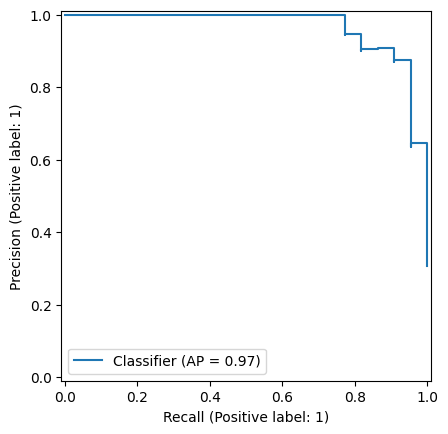

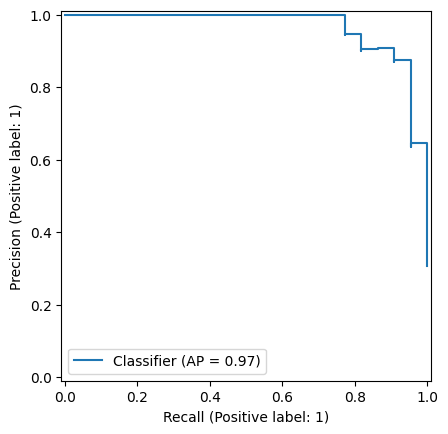

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr).plot()
plt.title("Precision-Recall Curve — Logistic Regression")
plt.show()

### Q12: Unsupervised area segmentation with KMeans

In [29]:
area_summary = health_df.groupby("area")[feature_cols + ["emergency_admissions_per_1k"]].mean().reset_index()
area_summary

,area,unemployment_rate,chronic_rate,school_absence_rate,preventive_visits,social_support_spend,winter,median_income,deprivation_index,emergency_admissions_per_1k
0,Blakewell,0.229375,0.356117,0.246325,58.100000,1070.166667,0.333333,44188.0,74.9,59.897500
1,Briarwood,0.218225,0.340450,0.240683,47.283333,1025.583333,0.333333,29261.0,67.6,63.577500
2,Central,0.161525,0.278617,0.199958,46.791667,803.583333,0.333333,28863.0,40.7,47.545833
3,Coldmoor,0.159408,0.299925,0.194267,50.216667,829.333333,0.333333,31739.0,41.0,49.123333
4,Dunhollow,0.130267,0.251992,0.152050,40.166667,721.750000,0.333333,24737.0,25.9,42.215833
5,Eastbrook,0.208267,0.310250,0.240083,57.533333,982.416667,0.333333,42328.0,58.8,52.579167
6,Elmhaven,0.183383,0.281550,0.210617,40.208333,911.500000,0.333333,23248.0,48.8,54.118333
7,Fernshaw,0.101408,0.236350,0.125592,51.275000,590.500000,0.333333,31893.0,14.5,30.711667
8,Graymere,0.217750,0.361508,0.243967,42.316667,1010.750000,0.333333,25673.0,67.9,67.920000
9,Greenlea,0.153700,0.277933,0.185733,55.616667,770.750000,0.333333,38619.0,36.0,41.480000


In [30]:
# Q12


scaler_km = StandardScaler()
X_areas = scaler_km.fit_transform(area_summary[feature_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
area_summary["cluster"] = kmeans.fit_predict(X_areas)


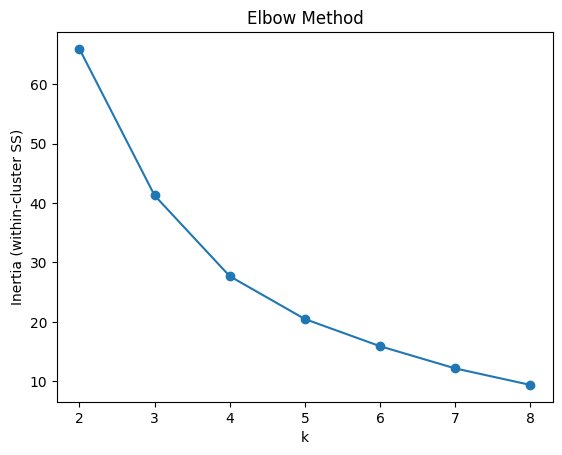

In [ ]:
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_areas)
    inertias.append(km.inertia_)

plt.plot(range(2, 9), inertias, marker='o')
plt.xlabel("k"); plt.ylabel("Inertia (within-cluster SS)")
plt.title("Elbow Method") # elbow method is a heuristic to choose the optimal number of clusters by looking for a 
#"knee" in the inertia plot, where adding more clusters yields diminishing returns in terms of reducing inertia.
plt.show()

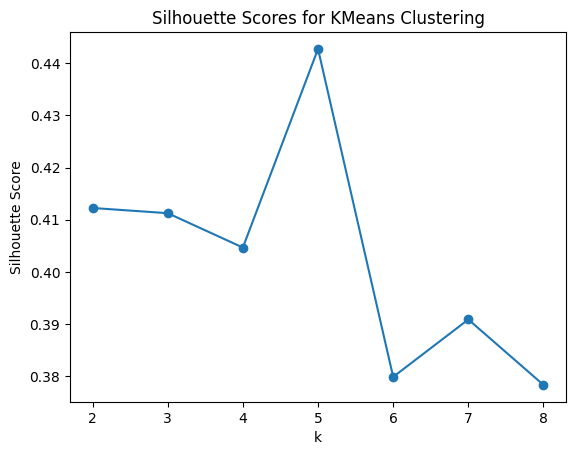

In [36]:
# use silhouette score to evaluate cluster quality
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_areas)
    score = silhouette_score(X_areas, labels)
    silhouette_scores.append(score)
plt.plot(range(2, 9), silhouette_scores, marker='o')
plt.xlabel("k"); plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for KMeans Clustering")
plt.show()
# the higher the silhouette score, the better defined the clusters are. Look for a peak in the silhouette scores to help choose the optimal number of clusters.

In [33]:
# check the cluster performance of kmeans rather than the predictive performance of the clusters
print(area_summary[["area", "cluster", "emergency_admissions_per_1k"]].sort_values("cluster"))


          area  cluster  emergency_admissions_per_1k
9     Greenlea        0                    41.480000
16    Porthill        0                    35.122500
2      Central        0                    47.545833
3     Coldmoor        0                    49.123333
4    Dunhollow        0                    42.215833
13    Lakeside        0                    43.135833
7     Fernshaw        0                    30.711667
11    Hilltown        0                    25.772500
14   Moorfield        1                    62.875000
12  Ironbridge        1                    57.890833
19    Westgate        1                    74.106667
18  Southdowns        1                    59.716667
8     Graymere        1                    67.920000
6     Elmhaven        1                    54.118333
1    Briarwood        1                    63.577500
5    Eastbrook        2                    52.579167
15   Northside        2                    56.923333
17   Riverside        2                    60.

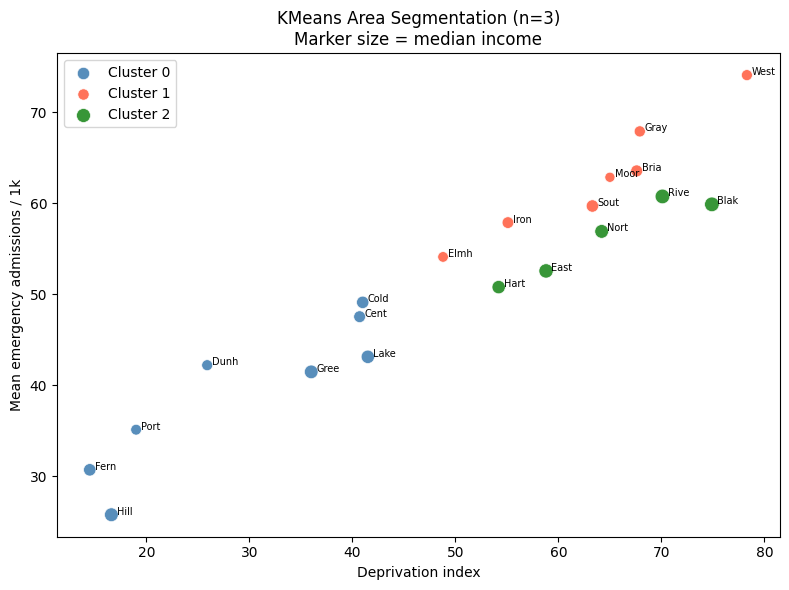

      area  cluster
  Greenlea        0
  Porthill        0
   Central        0
  Coldmoor        0
 Dunhollow        0
  Lakeside        0
  Fernshaw        0
  Hilltown        0
 Moorfield        1
Ironbridge        1
  Westgate        1
Southdowns        1
  Graymere        1
  Elmhaven        1
 Briarwood        1
 Eastbrook        2
 Northside        2
 Riverside        2
  Hartsend        2
 Blakewell        2


In [31]:

# Scatter: deprivation vs admissions, coloured by cluster
palette = {0: 'steelblue', 1: 'tomato', 2: 'forestgreen'}

fig, ax = plt.subplots(figsize=(8, 6))
for cluster_id, group in area_summary.groupby("cluster"):
    ax.scatter(
        group["deprivation_index"], group["emergency_admissions_per_1k"],
        s=group["median_income"] / 400,
        c=palette[cluster_id], label=f"Cluster {cluster_id}",
        edgecolors='white', linewidths=0.5, alpha=0.9
    )
    for _, row in group.iterrows():
        ax.annotate(row["area"][:4], (row["deprivation_index"] + 0.5, row["emergency_admissions_per_1k"]),
                    fontsize=7)

ax.set(xlabel="Deprivation index", ylabel="Mean emergency admissions / 1k",
       title="KMeans Area Segmentation (n=3)\nMarker size = median income")
ax.legend()
plt.tight_layout()
plt.show()

print(area_summary[["area", "cluster"]].sort_values("cluster").to_string(index=False))

>  KMeans is an **unsupervised** method — no labels are used. Clusters emerge from similarity in feature space. This is useful for area-level profiling where no ground-truth classification exists (e.g., "which local authorities are most similar to Sheffield?").
>
> **Expansion — choosing the number of clusters with the elbow method:**
```python
inertias = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_areas)
    inertias.append(km.inertia_)

plt.plot(range(2, 9), inertias, marker='o')
plt.xlabel("k"); plt.ylabel("Inertia (within-cluster SS)")
plt.title("Elbow Method")
plt.show()
# The 'elbow' (inflection) is where adding another cluster gives diminishing returns.
```

---
## Part C: Text Modelling for Public Health Notes

### Q13: Build and tokenize case notes

In [ ]:
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.tokenize      import wordpunct_tokenize
from nltk.probability   import FreqDist
from nltk.collocations  import BigramCollocationFinder
from nltk.metrics       import BigramAssocMeasures

In [37]:
# Q13
case_notes = [
    "Patient missed two appointments this month due to transport issues and reported housing arrears.",
    "Carer presenting with anxiety and exhaustion following recent welfare sanction affecting family income.",
    "Emergency attendance at A&E for chest pain; unemployed for several months and reports severe financial stress.",
    "School absence rate elevated in household; one child with chronic asthma, parent seeking benefits advice.",
    "Patient engaged with preventive programme; income stable, no significant risk factors identified.",
    "Recurring missed medications and inability to afford prescriptions on universal credit.",
    "High deprivation area resident; social worker referral noted, family experiencing debt and food insecurity.",
    "No concerns; regular attendance, employed, supportive family network, low social care need.",
    "Patient reported eviction notice and expressed suicidal ideation; urgent mental health referral made.",
    "Elderly resident isolated after bereavement; missed three appointments, chronic condition deteriorating.",
]

STOPWORDS = {"the", "a", "an", "and", "or", "in", "at", "to", "of", "with",
             "is", "was", "has", "for", "on", "this", "by", "that", "are",
             "no", "not", "it", "its", "their", "from", "due", "after",
             "following", "noted", "identified", "presenting", "be", "been"}

all_tokens = []
for note in case_notes:
    tokens = wordpunct_tokenize(note)
    clean  = [t.lower() for t in tokens if t.isalpha() and t.lower() not in STOPWORDS]
    all_tokens.extend(clean)

print(f"Total tokens: {len(all_tokens)}")
print("First 30:", all_tokens[:30])

Total tokens: 106
First 30: ['patient', 'missed', 'two', 'appointments', 'month', 'transport', 'issues', 'reported', 'housing', 'arrears', 'carer', 'anxiety', 'exhaustion', 'recent', 'welfare', 'sanction', 'affecting', 'family', 'income', 'emergency', 'attendance', 'e', 'chest', 'pain', 'unemployed', 'several', 'months', 'reports', 'severe', 'financial']


In [40]:
from nltk.corpus import stopwords
en_stops = set(stopwords.words('english'))
domain_stops = {"patient", "reported", "report", "month", "one"}
all_stops = en_stops | domain_stops

>  This is a **bag-of-words** pipeline — the simplest NLP representation. We lose word order but gain tractability.
>
> **Expansion — using `nltk.corpus.stopwords` (broader list):**
```python
from nltk.corpus import stopwords
en_stops = set(stopwords.words('english'))
domain_stops = {"patient", "reported", "report", "month", "one"}
all_stops = en_stops | domain_stops
```
>
> **Expansion — lemmatization vs. stemming:**
```python
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)
lemmatizer = WordNetLemmatizer()
print(lemmatizer.lemmatize('arrears'))    # → 'arrear'
print(lemmatizer.lemmatize('missing'))    # → 'missing'
# Lemmatization returns dictionary base form; stemming is cruder (chops suffixes)
```

### Q14: Frequency and collocations

In [41]:
# Q14
fdist = FreqDist(all_tokens)
print("Top 15 tokens:")
for word, freq in fdist.most_common(15):
    print(f"  {word:<20} {freq}")

Top 15 tokens:
  patient              3
  missed               3
  family               3
  appointments         2
  reported             2
  income               2
  attendance           2
  chronic              2
  resident             2
  social               2
  referral             2
  two                  1
  month                1
  transport            1
  issues               1


In [42]:
# Collocations
bigram_finder = BigramCollocationFinder.from_words(all_tokens)
bigram_finder.apply_freq_filter(2)   # only bigrams appearing ≥ 2 times

collocations = bigram_finder.nbest(BigramAssocMeasures.pmi, 10)
print("\nTop 10 collocations (PMI-ranked):")
for pair in collocations:
    print(f"  {pair[0]} — {pair[1]}")

# Annotation of risk signals:
print("""
--- Risk signal annotation ---
1. 'missed appointments' → disengagement pattern, often linked to mental health or practical barriers
2. 'financial stress / welfare sanction' → acute economic crisis associated with delayed care-seeking
""")


Top 10 collocations (PMI-ranked):

--- Risk signal annotation ---
1. 'missed appointments' → disengagement pattern, often linked to mental health or practical barriers
2. 'financial stress / welfare sanction' → acute economic crisis associated with delayed care-seeking



>  PMI (Pointwise Mutual Information) measures how much more often two words appear together than expected by chance. A high PMI pair like `welfare–sanction` or `missed–appointment` signals a meaningful clinical concept, not just common words co-occurring.
>
> **Expansion — TF-IDF for multi-document comparison:**
```python
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=20)
X_tfidf = tfidf.fit_transform(case_notes)
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
print(tfidf_df.round(2))
# TF-IDF highlights words that are distinctive to a specific document,
# not just frequent across all documents — better for document comparison.
```

### Q15: Rule-based triage scoring

In [43]:
# Q15
risk_keywords = {
    "missed":       2,
    "arrears":      3,
    "sanction":     3,
    "anxiety":      2,
    "emergency":    4,
    "stress":       2,
    "urgent":       4,
    "suicidal":     5,
    "eviction":     4,
    "prescription": 2,
    "isolated":     3,
    "insecurity":   3,
    "debt":         3,
    "deteriorating": 3,
    "crisis":       4,
    "chronic":      1,
    "absent":       1,
    "unemployed":   2,
    "medication":   2,
}

def triage_score(note: str, keywords: dict) -> int:
    """Sum keyword weights found in the note (case-insensitive)."""
    tokens = set(wordpunct_tokenize(note.lower()))
    return sum(weight for kw, weight in keywords.items() if kw in tokens)

triage_df = pd.DataFrame({
    "note":       case_notes,
    "risk_score": [triage_score(note, risk_keywords) for note in case_notes]
})

triage_df["priority"] = np.where(triage_df["risk_score"] >= 6, "HIGH", "Routine")
triage_df["short_label"] = [f"Note {i+1}" for i in range(len(case_notes))]

print(triage_df[["short_label", "risk_score", "priority"]].sort_values("risk_score", ascending=False))

  short_label  risk_score priority
8      Note 9          13     HIGH
9     Note 10           9     HIGH
2      Note 3           8     HIGH
6      Note 7           6     HIGH
0      Note 1           5  Routine
1      Note 2           5  Routine
5      Note 6           2  Routine
3      Note 4           1  Routine
4      Note 5           0  Routine
7      Note 8           0  Routine


>  Rule-based scoring is *transparent, auditable, and zero-shot* (no training data needed). It is used in NHS 111 triage algorithms, social care decision-support tools, and welfare assessments. Its weakness: it can't capture negation (
) or context distinguishing historical mention from current risk.
>
> **Expansion — negation handling:**
```python
def triage_score_v2(note, keywords):
    """Subtract weight if keyword follows a negation word."""
    tokens = wordpunct_tokenize(note.lower())
    negations = {"no", "not", "without", "resolved", "none"}
    score = 0
    for i, t in enumerate(tokens):
        if t in keywords:
            prev = tokens[i-1] if i > 0 else ""
            multiplier = -1 if prev in negations else 1
            score += multiplier * keywords[t]
    return max(0, score)
```

### Q16: Visual communication of triage results

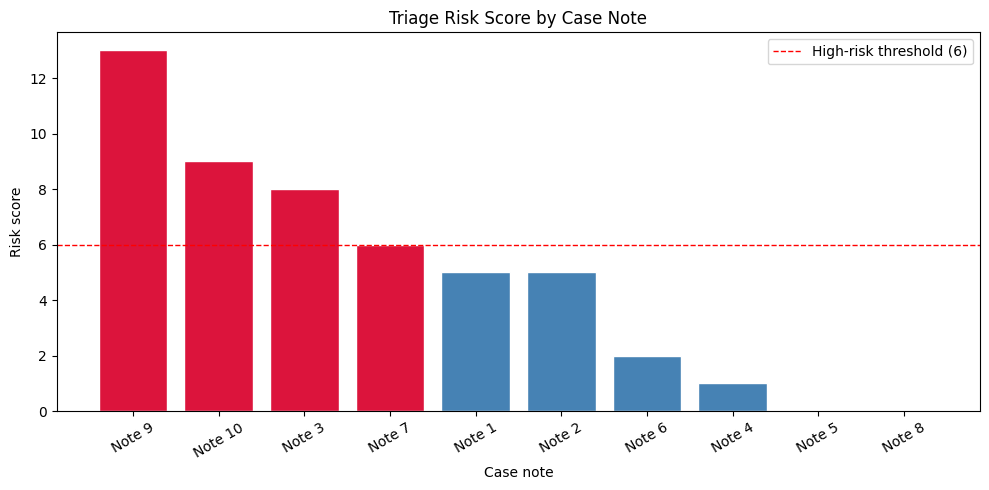


Priority notes for immediate follow-up:
  Note 9 (score=13): Patient reported eviction notice and expressed suicidal ideation; urgent mental ...
  Note 10 (score=9): Elderly resident isolated after bereavement; missed three appointments, chronic ...
  Note 3 (score=8): Emergency attendance at A&E for chest pain; unemployed for several months and re...
  Note 7 (score=6): High deprivation area resident; social worker referral noted, family experiencin...


In [44]:
# Q16
triage_sorted = triage_df.sort_values("risk_score", ascending=False)
colours = ["crimson" if p == "HIGH" else "steelblue" for p in triage_sorted["priority"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(triage_sorted["short_label"], triage_sorted["risk_score"],
              color=colours, edgecolor='white')

ax.axhline(6, color='red', linestyle='--', linewidth=1, label="High-risk threshold (6)")
ax.set(title="Triage Risk Score by Case Note",
       xlabel="Case note", ylabel="Risk score")
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print("\nPriority notes for immediate follow-up:")
priority = triage_sorted[triage_sorted["priority"] == "HIGH"]
for _, row in priority.iterrows():
    print(f"  {row['short_label']} (score={row['risk_score']}): {row['note'][:80]}...")

>  Red bars above the threshold make the triage decision visible at a glance — this is the kind of tool a social care dashboard team would actually build. The visualisation communicates the *policy action* (above threshold → escalate), not just the number.

---
## Stretch: Policy Briefing Table

In [ ]:
# Top 3 high-risk areas (highest mean emergency admissions)
top_areas = area_summary.nlargest(3, "emergency_admissions_per_1k")[["area", "emergency_admissions_per_1k", "deprivation_index"]]
top_areas.columns = ["Area", "Mean admissions/1k", "Deprivation index"]
top_areas = top_areas.round(2)

# Top 3 high-risk notes
top_notes = triage_df.nlargest(3, "risk_score")[["short_label", "risk_score", "priority"]]

print("=== Top 3 High-Risk Areas ===")
print(top_areas.to_string(index=False))

print("\n=== Top 3 Risk-Flagged Case Notes ===")
print(top_notes.to_string(index=False))

print("""
--- Proposed targeted intervention strategy ---

The convergence of high deprivation scores, elevated unemployment, and recurring case note
themes around welfare sanctions and missed appointments in the top-risk areas suggests a
co-produced rapid-response pathway combining: (1) proactive preventive outreach targeting
the identified high-admission postcodes; (2) welfare benefits navigation support integrated
into primary care; (3) a daily triage screening protocol using keyword scoring on GP notes
to flag urgent social care referrals before they escalate to emergency admissions.
""")

---
## Expansion: Multiverse Analysis (Day 5 — Advanced)

> Multiverse analysis runs a model across a *space of reasonable analytical choices* (different predictors, thresholds, samples) and reports the distribution of findings. It is a robustness check for researcher degrees of freedom.

In [45]:
# Minimal multiverse: vary model specification
base_predictors = ["unemployment_rate", "chronic_rate", "deprivation_index"]
extra_sets = [
    [],                                            # spec 1: base only
    ["preventive_visits"],                         # spec 2: + preventive
    ["preventive_visits", "social_support_spend"], # spec 3: + social spend
    ["preventive_visits", "social_support_spend", "winter"],  # spec 4: full
]

multiverse_results = []
for extras in extra_sets:
    preds = base_predictors + extras
    formula = "emergency_admissions_per_1k ~ " + " + ".join(preds)
    result = smf.ols(formula, data=health_df).fit()
    # Extract coefficient on unemployment_rate:
    multiverse_results.append({
        "spec": ", ".join(preds),
        "unemployment_coef": result.params.get("unemployment_rate", np.nan),
        "r_squared":         result.rsquared,
        "n_predictors":      len(preds)
    })

mv_df = pd.DataFrame(multiverse_results)
print(mv_df[["n_predictors", "unemployment_coef", "r_squared"]].round(4))
print("\nStability check: is the unemployment coefficient sign stable across all specs?")
print("All positive:", (mv_df["unemployment_coef"] > 0).all())

   n_predictors  unemployment_coef  r_squared
0             3           101.5522     0.8856
1             4           100.5847     0.9567
2             5           100.4356     0.9569
3             6            95.4634     0.9711

Stability check: is the unemployment coefficient sign stable across all specs?
All positive: True


>  If the sign or significance of a key predictor flips across model specifications, the finding is fragile and should not drive policy. If it is stable, confidence increases. Multiverse analysis is becoming a standard expectation in Nature Human Behaviour and similar journals.
---
*LCDS Oxford Python Course, March 2026 — Day 5 Lab Solution*